# Week 1 Seminar

A/B experiment analysis

In [1]:
import glob
from collections import namedtuple

import pandas as pd
import numpy as np
import scipy.stats as ss

import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

%matplotlib inline

In [2]:
experiment = "I2I"

In [3]:
data = pd.concat([
    pd.read_json(data_path, lines=True)
    for data_path
    in glob.glob("/Users/n.anokhin/Desktop/data/*/data.json")
])

data["treatment"] = data["experiments"].map(lambda experiments: experiments[experiment])

In [4]:
data

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2026-03-11 19:43:34.422,2423,14801,0.51,3.458e-03,14802.0,{'I2I': 'T1'},T1
1,next,2026-03-11 19:43:34.430,2423,3472,0.80,5.953e-04,14740.0,{'I2I': 'T1'},T1
2,next,2026-03-11 19:43:39.401,678,7248,1.00,5.018e+00,5049.0,{'I2I': 'T2'},T2
3,next,2026-03-11 19:43:39.414,678,5049,0.24,1.609e-03,9730.0,{'I2I': 'T2'},T2
4,next,2026-03-11 19:43:39.425,678,11995,0.04,1.381e-03,8659.0,{'I2I': 'T2'},T2
...,...,...,...,...,...,...,...,...,...
50846,next,2026-03-11 19:45:50.708,1875,1855,0.36,5.805e-04,15481.0,{'I2I': 'T2'},T2
50847,next,2026-03-11 19:45:50.716,1875,1856,0.43,5.028e-04,12775.0,{'I2I': 'T2'},T2
50848,next,2026-03-11 19:45:50.722,1875,7749,0.15,5.088e-04,6630.0,{'I2I': 'T2'},T2
50849,next,2026-03-11 19:45:50.740,8897,8026,0.56,5.517e-04,8183.0,{'I2I': 'T2'},T2


In [6]:
data.groupby("treatment").count()

,message,timestamp,user,track,time,latency,recommendation,experiments
treatment,,,,,,,,
C,57668,57668,57668,57668,57668,57668,51116,57668
T1,65687,65687,65687,65687,65687,65687,58898,65687
T2,80051,80051,80051,80051,80051,80051,73392,80051


## Visualize sessions

In [7]:
Session = namedtuple("Session", ["timestamp", "tracks", "time", "latency"])

def sessionize(user_data):
    sessions = []
    session = None
    for _, row in user_data.sort_values("timestamp").iterrows():
        if session is None:
            session = Session(row["timestamp"], 0, 0, 0)
        
        session = session._replace(
            tracks = session.tracks + 1, 
            time = session.time + row["time"],
            latency = session.latency + row["latency"] * 1000,
        )
        
        if row["message"] == "last":
            sessions.append(session._asdict())
            session = None
    return sessions

In [8]:
sessions = (
    data
    .groupby(["user", "treatment"])
    .apply(sessionize)
    .explode()
    .apply(pd.Series)
)

/var/folders/vq/_5djr0p11jv95fzz1mx_9f480000gp/T/ipykernel_53472/2354129256.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data


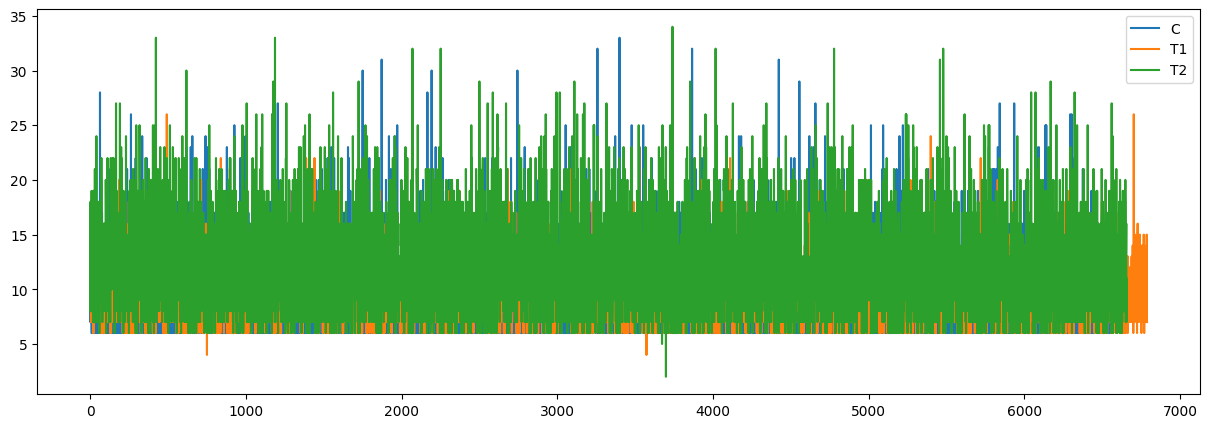

In [9]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["tracks"], label=treatment)
ax.legend()
pass

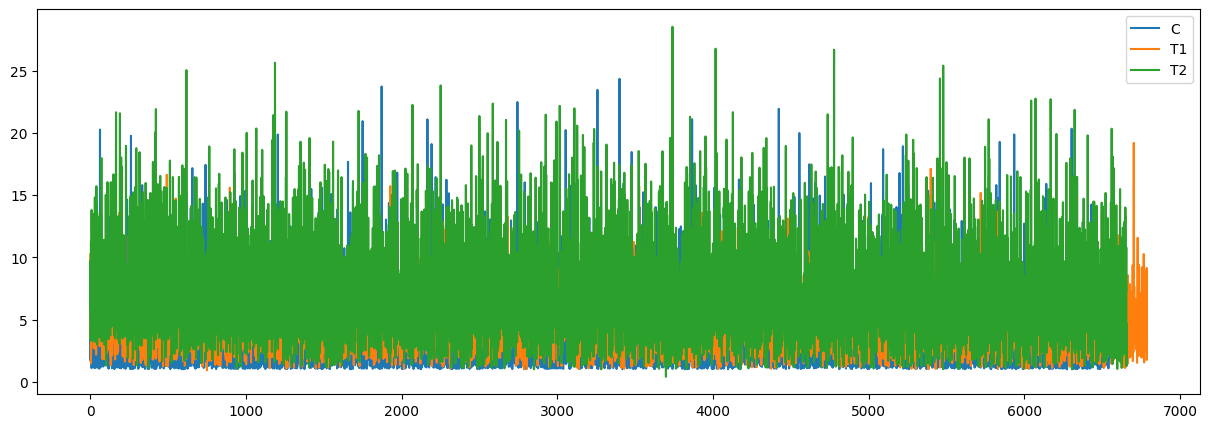

In [10]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["time"], label=treatment)
ax.legend()
pass

## Analyze the experiment

In [11]:
user_level_data = (
  sessions
    .reset_index()
    .groupby(["user", "treatment"])
    .agg(
        {
            "timestamp": "count",
            "tracks": "sum",
            "time": "sum",
            "latency": "sum"
        }
    )
)

user_level_data["sessions"] = user_level_data["timestamp"]
user_level_data["mean_request_latency"] = user_level_data["latency"] / user_level_data["tracks"]
user_level_data["mean_tracks_per_session"] = user_level_data["tracks"] / user_level_data["sessions"]
user_level_data["mean_time_per_session"] = user_level_data["time"] / user_level_data["sessions"]

metrics = [
    "time", 
    "sessions", 
    "mean_request_latency", 
    "mean_tracks_per_session", 
    "mean_time_per_session"
]

user_level_metrics = user_level_data[metrics].copy().reset_index()

In [12]:
treatment_level_metrics = (
    user_level_metrics
    .groupby("treatment")[metrics]
    .agg(["count", "mean", "var"])
)

In [13]:
def dof(n_0, n_1, s2_0, s2_1):
    numerator = (s2_0 / n_0 + s2_1 / n_1) * (s2_0 / n_0 + s2_1 / n_1)
    denominator = s2_0 * s2_0 / n_0 / n_0 / (n_0 - 1) + s2_1 * s2_1 / n_1 / n_1 / (n_1 - 1)
    return numerator / denominator


def ci(n_0, n_1, s2_0, s2_1, alpha=0.05):
    return ss.t.ppf(1 - alpha/2, dof(n_0, n_1, s2_0, s2_1)) * np.sqrt(s2_0 / n_0 + s2_1 / n_1)


effects = []

control = [data for treatment, data in treatment_level_metrics.iterrows() if treatment == "C"][0]

for treatment, row in treatment_level_metrics.iterrows():
    if treatment == "C":
        continue
    
    for metric in metrics:
        control_mean = control[metric]["mean"]
        treatment_mean = row[metric]["mean"]
        
        effect = treatment_mean - control_mean
        conf_int = ci(
            control[metric]["count"],
            row[metric]["count"],
            control[metric]["var"],
            row[metric]["var"],
        )
        effects.append({
            "treatment": treatment,
            "metric": metric,
            "control_mean": control_mean,
            "treatment_mean": treatment_mean,
            "effect": effect / control_mean * 100,
            "lower": (effect - conf_int) / control_mean * 100,
            "upper": (effect + conf_int) / control_mean * 100,
            "significant": (effect + conf_int) * (effect - conf_int) > 0
        })

In [15]:
def color(value):
    return 'color:red;' if value < 0 else 'color:green;'

def background(value):
    return 'color:white;background-color:green' if value else 'color:white;background-color:red'
        

(
    pd.DataFrame(effects)[[
        "treatment", 
        "metric",
        "effect", 
        "upper", 
        "lower", 
        "control_mean", 
        "treatment_mean",
        "significant"
    ]]
    .sort_values(["metric", "treatment"], ascending=True)
    .style
    .applymap(color, subset=["effect", "upper", "lower"])
    .applymap(background, subset=["significant"])
)

/var/folders/vq/_5djr0p11jv95fzz1mx_9f480000gp/T/ipykernel_53472/4013875030.py:9: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  pd.DataFrame(effects)[[


,treatment,metric,effect,upper,lower,control_mean,treatment_mean,significant
2,T1,mean_request_latency,-3.160992,43.651809,-49.973794,0.643247,0.622914,False
7,T2,mean_request_latency,-0.260610,45.761704,-46.282924,0.643247,0.641571,False
4,T1,mean_time_per_session,24.439036,27.710324,21.167748,3.736942,4.650214,True
9,T2,mean_time_per_session,92.565597,96.918792,88.212402,3.736942,7.196064,True
3,T1,mean_tracks_per_session,10.556150,12.162724,8.949577,8.740890,9.663591,True
8,T2,mean_tracks_per_session,39.665382,41.707644,37.623120,8.740890,12.207997,True
1,T1,sessions,2.197802,5.080357,-0.684753,2.275000,2.325000,False
6,T2,sessions,2.666888,5.545608,-0.211832,2.275000,2.335672,False
0,T1,time,25.861901,30.791579,20.932222,8.630559,10.862586,True
5,T2,time,89.814372,95.977501,83.651242,8.630559,16.382041,True
